In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from Constants import Const
import SymptomPreprocessing as Symptom
import re

In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
#preface: the goal of this part is to do the preprocessing to get the data needed for the clustering
temp = pd.read_csv(Const.data_dir+'minimal_dose_cluster_dataset.csv')
#the version I use has a bunch of optional preprocessing stuff
#main things: id, dose values ("DX" or "VX"), demographics + treatment info, and symptoms (symptoms_<name>)
#included in this exampe is also non-imputed symptoms (symptoms_<name>_original), and experimental symptom groups which will not be done in this notebook code example
for col in temp.columns:
    #skip similar values for the symptoms ect
    if 'symptoms' in col and 'drymouth' not in col:
        continue
    if len(col) == 3 and col[0] in ['V','D']:
        continue
    print(col,temp[col].iloc[0])
    print()

id 2

D2 [54.53125, 28.1875, 59.84375, 57.40625, 55.9375, 63.71875, 56.125, 73.1875, 26.53125, 70.375, 71.0625, 60.875, 55.90625, 56.125, 63.46875, 43.90625, 36.6875, 72.5625, 58.84375, 67.8125, 72.375, 73.0, 61.5, 60.875, 73.0625, 72.875, 64.9375, 72.5625, 73.1875, 72.375, 72.625, 58.90625, 72.375, 72.1875, 72.5625, 71.875, 52.875, 35.5625, 20.453125, 48.5625]

D5 [53.21875, 27.4375, 58.28125, 55.5, 54.90625, 60.875, 53.3125, 73.0, 24.875, 62.65625, 69.875, 60.5, 55.71875, 52.53125, 60.84375, 38.21875, 34.8125, 72.125, 57.71875, 59.6875, 72.25, 72.625, 55.84375, 58.25, 72.5625, 72.4375, 63.90625, 72.3125, 72.8125, 72.1875, 72.3125, 51.375, 71.8125, 71.875, 72.25, 71.1875, 41.125, 32.375, 17.234375, 44.96875]

V5 [96.375, 100.0, 95.6875, 100.0, 100.0, 100.0, 100.0, 100.0, 30.71875, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 93.6875, 97.375, 100.0, 100.0, 100.0, 100.0, 100.0, 91.9375, 97.875, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 100.0, 99.6875, 87.75, 100

In [4]:
#symptom data is an array that coresponds to the dates in the "dates" column, in terms of weeks since treatment start
import json
temps, tempdates = [json.loads(x) for x in temp[['symptoms_drymouth','dates']].iloc[0].tolist()]
for s,d in zip(temps,tempdates):
    print('symptoms at '+str(d) + ' weeks: ' + str(s) + ' out of 10')

symptoms at 0 weeks: 0.0 out of 10
symptoms at 1 weeks: 3.0 out of 10
symptoms at 2 weeks: 2.0 out of 10
symptoms at 3 weeks: 3.0 out of 10
symptoms at 4 weeks: 4.0 out of 10
symptoms at 5 weeks: 4.0 out of 10
symptoms at 6 weeks: 4.0 out of 10
symptoms at 7 weeks: 4.0 out of 10
symptoms at 13 weeks: 8.0 out of 10
symptoms at 33 weeks: 4.0 out of 10
symptoms at 59 weeks: 3.0 out of 10
symptoms at 85 weeks: 5.0 out of 10
symptoms at 268 weeks: 0.0 out of 10


In [5]:
#organ values (DX, VX, mean_dose, volume), are arrays ordered by the order in Const.organ_list
#if this changes it also needs to be reflected in the Constants in the react frontend
for value, organ in zip(json.loads(temp.D15.iloc[0]), Const.organ_list):
    print('D15 to '  + organ + ': ' + str(value) + ' greys')

D15 to Esophagus: 49.78125 greys
D15 to Spinal_Cord: 26.515625 greys
D15 to Lt_Brachial_Plexus: 54.6875 greys
D15 to Rt_Brachial_Plexus: 52.21875 greys
D15 to Cricopharyngeal_Muscle: 52.96875 greys
D15 to Cricoid_cartilage: 56.1875 greys
D15 to IPC: 47.5 greys
D15 to MPC: 72.3125 greys
D15 to Brainstem: 19.703125 greys
D15 to Larynx: 54.21875 greys
D15 to Thyroid_cartilage: 64.0 greys
D15 to Rt_Sternocleidomastoid_M: 60.03125 greys
D15 to Rt_Mastoid: 54.5 greys
D15 to Rt_Parotid_Gland: 42.09375 greys
D15 to Rt_Medial_Pterygoid_M: 56.53125 greys
D15 to Rt_Lateral_Pterygoid_M: 31.65625 greys
D15 to Rt_Masseter_M: 31.953125 greys
D15 to Lt_Sternocleidomastoid_M: 70.9375 greys
D15 to Lt_Mastoid: 54.125 greys
D15 to Lt_Parotid_Gland: 43.65625 greys
D15 to Lt_Submandibular_Gland: 72.0 greys
D15 to Lt_Medial_Pterygoid_M: 72.125 greys
D15 to Lt_Lateral_Pterygoid_M: 42.46875 greys
D15 to Lt_Masseter_M: 52.375 greys
D15 to Supraglottic_Larynx: 72.0625 greys
D15 to SPC: 71.9375 greys
D15 to Rt_Su

In [6]:
#Dataset provided is a row for each organ, with ID, and dose information

In [7]:
# base_df = pd.read_excel(Const.data_dir + 'Cohort_SMART2_530pts_(486pts).xlsx')
base_df = pd.read_csv(Const.data_dir + 'dvh_20260421.csv')
base_df.head()

,id,Structure,Volume,mean,minGy,maxGy,V5,V10,V15,V20,...,D70,D75,D80,D85,D90,D95,D97,D98,D99,DicomType
0,1034,Hyoid_bone,3.5201,70.9873,69.9,71.7,100.0000,100.0000,100.0000,100.0000,...,70.8640,70.8133,70.7627,70.7121,70.6237,70.5234,70.4502,70.3906,70.3310,ORGAN
1,1034,Mandible,98.2159,37.1050,3.5,70.9,99.7285,96.0087,93.7408,89.9127,...,25.3946,23.8739,22.8103,21.7711,19.9465,11.8452,8.5224,7.1977,5.9667,ORGAN
2,1034,Lt_Mastoid,1.7854,41.1013,26.1,50.7,100.0000,100.0000,100.0000,100.0000,...,38.7900,37.4250,36.1320,34.5117,32.4300,30.1900,28.8935,28.2580,27.4290,ORGAN
3,1034,Rt_Mastoid,0.9653,36.5273,23.5,46.3,100.0000,100.0000,100.0000,100.0000,...,34.1900,33.2250,32.3800,31.0950,29.3400,27.5300,26.4580,25.4720,24.0720,ORGAN
4,1034,Lt_Brachial_Plexus,6.0615,47.2778,6.7,62.9,100.0000,98.9421,95.1281,91.2027,...,47.3640,46.0385,39.3400,29.2400,21.4800,15.1533,12.5940,11.4280,9.8920,ORGAN


In [8]:
#I map the names here to the original names in CAMPRT (originally for use with the spatial data, can be ignored if redone)
#The current code has a spellchecker, which is redundant with this list
organ_rename_dict  = {
    'cricoid': 'Cricoid_cartilage',
 'cricopharyngeus': 'Cricopharyngeal_Muscle',
 'esophagus_u': 'Esophagus',
 'oral_cavity': 'Extended_Oral_Cavity',
 'musc_geniogloss': 'Genioglossus_M',
 'hardpalate': 'Hard_Palate',
 'bone_hyoid': 'Hyoid_bone',
 'musc_constrict_i': 'IPC',
 'lips_lower': 'Lower_Lip',
 'lips_upper': 'Upper_Lip',
 'musc_constrict_m': 'MPC',
 'musc_mgh_complex': 'Mylogeniohyoid_M',
 'musc_mghcomplex': 'Mylogeniohyoid_M',
 'palate_soft': 'Soft_Palate',
 'musc_constrict_s': 'SPC',
 'spinalcord_cerv': 'Spinal_Cord',
 'larynx_sg': 'Supraglottic_Larynx',
 'cartlg_thyroid': 'Thyroid_cartilage',
 'brachial_plex_r': 'Rt_Brachial_Plexus',
 'brachial_plex_l': 'Lt_Brachial_Plexus',
 'pterygoid_lat_r': 'Rt_Lateral_Pterygoid_M',
 'pterygoid_lat_l': 'Lt_Lateral_Pterygoid_M',
 'musc_masseter_r': 'Rt_Masseter_M',
 'musc_masseter_l': 'Lt_Masseter_M',
 'bone_mastoid_r': 'Rt_Mastoid',
 'bone_mastoid_l': 'Lt_Mastoid',
 'pterygoid_med_r': 'Rt_Medial_Pterygoid_M',
 'pterygoid_med_l': 'Lt_Medial_Pterygoid_M',
 'parotid_r': 'Rt_Parotid_Gland',
 'parotid_l': 'Lt_Parotid_Gland',
 'musc_sclmast_r': 'Rt_Sternocleidomastoid_M',
 'musc_sclmast_l': 'Lt_Sternocleidomastoid_M',
 'glnd_submand_r': 'Rt_Submandibular_Gland',
 'glnd_submand_l': 'Lt_Submandibular_Gland',
 'musc_digastric_ra': 'Rt_Ant_Digastric_M',
 'musc_digastric_la': 'Lt_Ant_Digastric_M',
 'musc_digastric_rp': 'Rt_Post_Digastric_M',
 'musc_digastric_lp': 'Lt_Post_Digastric_M'
}

In [9]:
#rename headers to be consisent with CAMPRT Dataset
file_header_renames = {
        'mean': 'mean_dose',
        'Volume': 'volume',
        'minGy': 'min_dose',
        'maxGy': 'max_dose',
    }
df = base_df.rename(file_header_renames,axis=1)
df['ROI'] = df.Structure.apply(lambda x: organ_rename_dict.get(x.lower(),x))
df = df[df['DicomType'] =='ORGAN'].drop('DicomType',axis=1)
df.head()

,id,Structure,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,...,D70,D75,D80,D85,D90,D95,D97,D98,D99,ROI
0,1034,Hyoid_bone,3.5201,70.9873,69.9,71.7,100.0000,100.0000,100.0000,100.0000,...,70.8640,70.8133,70.7627,70.7121,70.6237,70.5234,70.4502,70.3906,70.3310,Hyoid_bone
1,1034,Mandible,98.2159,37.1050,3.5,70.9,99.7285,96.0087,93.7408,89.9127,...,25.3946,23.8739,22.8103,21.7711,19.9465,11.8452,8.5224,7.1977,5.9667,Mandible
2,1034,Lt_Mastoid,1.7854,41.1013,26.1,50.7,100.0000,100.0000,100.0000,100.0000,...,38.7900,37.4250,36.1320,34.5117,32.4300,30.1900,28.8935,28.2580,27.4290,Lt_Mastoid
3,1034,Rt_Mastoid,0.9653,36.5273,23.5,46.3,100.0000,100.0000,100.0000,100.0000,...,34.1900,33.2250,32.3800,31.0950,29.3400,27.5300,26.4580,25.4720,24.0720,Rt_Mastoid
4,1034,Lt_Brachial_Plexus,6.0615,47.2778,6.7,62.9,100.0000,98.9421,95.1281,91.2027,...,47.3640,46.0385,39.3400,29.2400,21.4800,15.1533,12.5940,11.4280,9.8920,Lt_Brachial_Plexus


<Axes: >

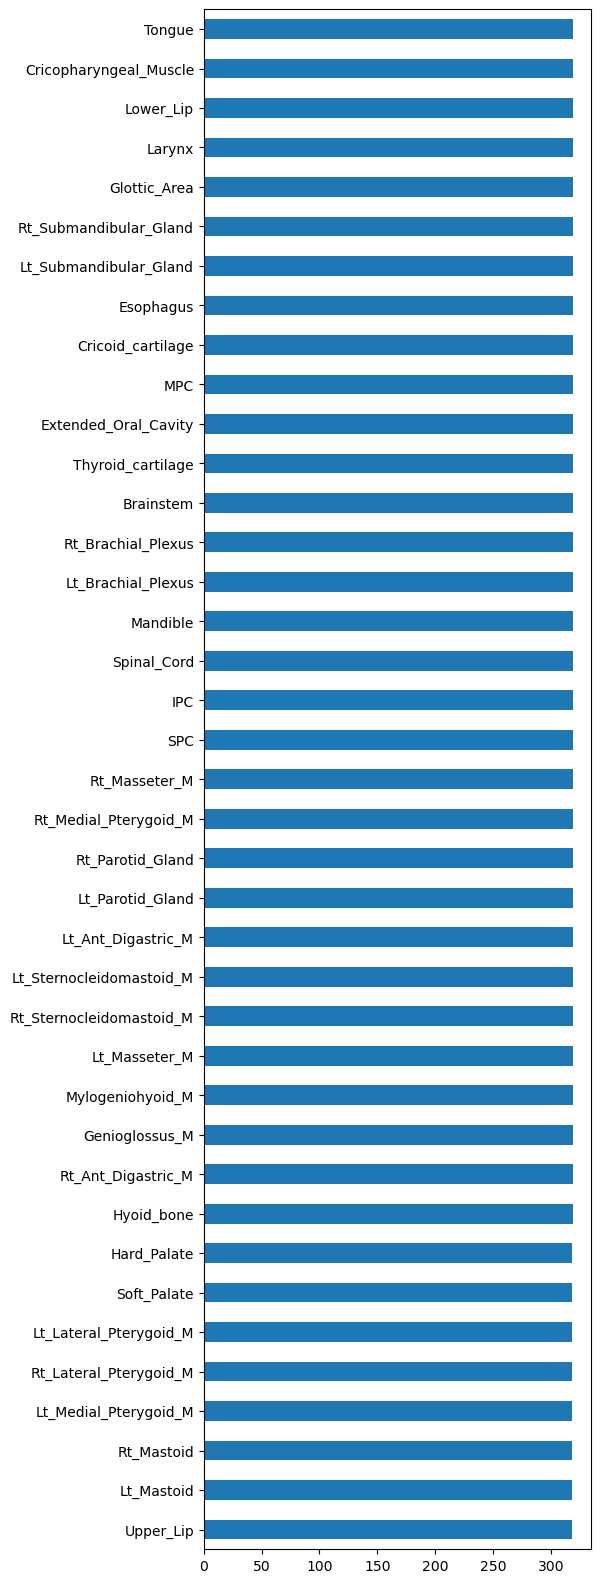

In [10]:
#The organ counts are variable. and have name inconsistencies. These will probably be different on a different dataset
organ_counts = {}
for _,row in df.iterrows():
    count = organ_counts.get(row['ROI'],0)
    organ_counts[row['ROI']] = count + 1
pd.Series(organ_counts).sort_values().plot(kind='barh',ax=plt.subplots(1,1,figsize=(5,20))[1])

In [11]:
#For reference, I use a static organ list that is the organs I select for and is also a fixed order for arrays of organ values
Const.organ_list

['Esophagus',
 'Spinal_Cord',
 'Lt_Brachial_Plexus',
 'Rt_Brachial_Plexus',
 'Cricopharyngeal_Muscle',
 'Cricoid_cartilage',
 'IPC',
 'MPC',
 'Brainstem',
 'Larynx',
 'Thyroid_cartilage',
 'Rt_Sternocleidomastoid_M',
 'Rt_Mastoid',
 'Rt_Parotid_Gland',
 'Rt_Medial_Pterygoid_M',
 'Rt_Lateral_Pterygoid_M',
 'Rt_Masseter_M',
 'Lt_Sternocleidomastoid_M',
 'Lt_Mastoid',
 'Lt_Parotid_Gland',
 'Lt_Submandibular_Gland',
 'Lt_Medial_Pterygoid_M',
 'Lt_Lateral_Pterygoid_M',
 'Lt_Masseter_M',
 'Supraglottic_Larynx',
 'SPC',
 'Rt_Submandibular_Gland',
 'Hyoid_bone',
 'Soft_Palate',
 'Genioglossus_M',
 'Tongue',
 'Rt_Ant_Digastric_M',
 'Lt_Ant_Digastric_M',
 'Mylogeniohyoid_M',
 'Extended_Oral_Cavity',
 'Mandible',
 'Hard_Palate',
 'Lower_Lip',
 'Upper_Lip',
 'Glottic_Area']

In [12]:
#In the dass code, the spellchecker was there to fix organ names and align them with the CAMPRT dataset, 
#which is what I was working on at the beginning of the project
#Furture projects will probably have a seperate thing.

In [13]:
#General Data Cleanup, may be required in future datasets
#enforce value columns to be numbers
def fix_df(df):
    df = df.drop_duplicates(subset=['id','ROI','volume'])
    df = df[df.mean_dose != 'error']
    #make sure volume and dose fields are actual numbers
    for col in df.columns:
        if 'dose' in col.lower() or 'volume' in col.lower():
            df[col] = df[col].astype(float)
    hist_cols = [c for c in df.columns if (re.match(r'[DV]\d+',c) is not None)]
    df[hist_cols] = df[hist_cols].astype('float16')
    df = df[~df.id.isna()]
    df['id'] = df.id.astype(int)
    return df
    

df = fix_df(df)
df.head()

,id,Structure,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,...,D70,D75,D80,D85,D90,D95,D97,D98,D99,ROI
0,1034,Hyoid_bone,3.5201,70.9873,69.9,71.7,100.00,100.0000,100.000,100.0000,...,70.875000,70.81250,70.75000,70.687500,70.625000,70.50000,70.437500,70.375000,70.312500,Hyoid_bone
1,1034,Mandible,98.2159,37.1050,3.5,70.9,99.75,96.0000,93.750,89.9375,...,25.390625,23.87500,22.81250,21.765625,19.953125,11.84375,8.523438,7.199219,5.964844,Mandible
2,1034,Lt_Mastoid,1.7854,41.1013,26.1,50.7,100.00,100.0000,100.000,100.0000,...,38.781250,37.43750,36.12500,34.500000,32.437500,30.18750,28.890625,28.265625,27.421875,Lt_Mastoid
3,1034,Rt_Mastoid,0.9653,36.5273,23.5,46.3,100.00,100.0000,100.000,100.0000,...,34.187500,33.21875,32.37500,31.093750,29.343750,27.53125,26.453125,25.468750,24.078125,Rt_Mastoid
4,1034,Lt_Brachial_Plexus,6.0615,47.2778,6.7,62.9,100.00,98.9375,95.125,91.1875,...,47.375000,46.03125,39.34375,29.234375,21.484375,15.15625,12.593750,11.429688,9.890625,Lt_Brachial_Plexus


In [14]:
def filter_valid_patients(df,organ_list, max_missing_ratio=.5,print_out=True):
    df = df.copy()
    dfs = []
    for pid,subdf in df.groupby('id'):
        
        rois = set([i for i in np.unique(subdf.ROI) if i in organ_list])
        n_rois = len(rois)
        n_missing = np.abs(n_rois - len(organ_list))
        if print_out:
            if n_missing != 0:
                print('patient ', pid, 'has', n_missing,'organs off')
        if subdf[subdf.duplicated(subset=['ROI','Structure'],keep=False)].loc[:,['ROI','Structure']].shape[0] > 0:
            print('patient',pid,'has duplicate organs?')
            print(subdf[subdf.duplicated(subset=['ROI','Structure'],keep=False)].loc[:,['ROI','Structure']])
        max_missing = len(organ_list)*max_missing_ratio
        flag = (n_missing < max_missing)
        if flag:
            dfs.append(subdf)
    valid_df = pd.concat(dfs)
    print('valid patients:',len(valid_df.id.unique()),'out of',len(df.id.unique()))
    return valid_df

##This code filters patients based on certain missing values. Here are removing people with more than half the organs in Const.organ_list
filtered_df = filter_valid_patients(df,Const.organ_list,print_out=False)

valid patients: 319 out of 319


In [15]:
#add in missing organs from organ_list for each patient
#so when we turn it into an array the values will be there
#by default, these are nan
def add_patient_organs(pid,patient_df,organ_list):
    pdf = patient_df.copy()
    rois = np.unique(patient_df.ROI.values)
    for organ in organ_list:
        if organ not in rois:
            entry = pd.Series([pid,'missing',organ],index=['id','Structure','ROI'])
            pdf = pd.concat([pd.DataFrame(entry).T,pdf],ignore_index=True)
    return pdf

def add_missing_organs(df,organ_list):
    dfs = []
    for pid,subdf in df.groupby('id'):
        subdf = add_patient_organs(pid,subdf,organ_list).set_index("ROI")
        subdf = subdf.loc[organ_list]
        subdf = subdf.reset_index()
        dfs.append(subdf)
    return pd.concat(dfs)

clean_df = add_missing_organs(filtered_df,Const.organ_list)
clean_df.head()

,ROI,id,Structure,volume,mean_dose,min_dose,max_dose,V5,V10,V15,...,D65,D70,D75,D80,D85,D90,D95,D97,D98,D99
0,Esophagus,31,Esophagus,13.0376,12.1687,0.0,48.9,50.71875,48.0000,44.09375,...,1.371094,1.111328,0.901855,0.745605,0.520508,0.356689,0.119324,0.064392,0.042908,0.021500
1,Spinal_Cord,31,Spinal_Cord,23.4596,10.1620,0.0,19.1,69.43750,66.0625,30.59375,...,10.210938,4.187500,1.410156,0.998535,0.766113,0.512207,0.286377,0.154541,0.092102,0.045990
2,Lt_Brachial_Plexus,31,Lt_Brachial_Plexus,5.2447,42.7918,2.5,62.1,97.31250,87.8125,82.31250,...,47.000000,42.250000,26.078125,18.234375,12.304688,8.757812,6.070312,5.152344,4.703125,4.117188
3,Rt_Brachial_Plexus,31,Rt_Brachial_Plexus,4.8634,47.0311,14.1,58.9,100.00000,100.0000,99.93750,...,46.531250,44.375000,40.718750,37.062500,33.718750,29.546875,25.343750,23.265625,22.093750,20.375000
4,Cricopharyngeal_Muscle,31,Cricopharyngeal_Muscle,2.3186,17.7208,13.3,32.9,100.00000,100.0000,79.62500,...,15.804688,15.546875,15.250000,14.976562,14.734375,14.445312,14.023438,13.796875,13.671875,13.539062


In [16]:
def get_value_array(df,cols,organ_list,input_median=True, rows='patients',as_df=True):
    #returns a value array, with rows=patients, it will roll up the organs for a paeitn
    #keep_d2 set to false will return a 3d matrix where the second dimension is the organs in same order as organ list
    #as_df needs to be 2d, will include headers and ID
    #cols is the value arrays to inclue from
    if 'Structure' in cols or 'ROI' in cols:
        cols = list(set(cols) - set(['Structure','ROI']))
    cols = [c for c in cols if c not in ['Structure','ROI','id']]
    try:
        subdf = df[cols].astype(float)
        subdf['id'] = df.id
        subdf['ROI'] = df['ROI']
        subdf = subdf[subdf.ROI.isin(organ_list)]
    except Exception as e:
        print('error getting values as floats')
        print(e)
    if input_median:
        for col in cols:
            nanvals = np.isnan(subdf[col])
            subdf.loc[nanvals,col] = subdf[~nanvals][col].median()
    if rows== 'organs':
        if as_df:
            return subdf
        else:
            return subdf.drop(['id','ROI'],axis=1).values
    else:
        assert(rows=='patients')
        values = []
        pids = sorted(subdf.id.unique())
        colnames =[]
        for roi in subdf.ROI.unique():
            for c in subdf.columns:
                if c != 'id' and c != 'ROI':
                    colnames.append(roi + '_' + c)
        for pid in pids:
            pdf = subdf[subdf.id == pid]
#             for pid, pdf in subdf.groupby('id'):
#                 pids.append(pid)
            pdf = pdf[pdf.ROI.apply(lambda x: x in organ_list)]
            rows = pdf.drop(['id','ROI'],axis=1)
            values.append(rows.values.ravel())
        if as_df:
            returndf = pd.DataFrame(np.array(values),index=pids,columns=colnames)
            returndf.index.name = 'id'
            return returndf
        else:
            values = np.array(values)
            return values

#this will roll up the dvh dataframe to be per-patient instead of per ROI
#second argument is the list of columns to input
#third argument is list of organs
get_value_array(clean_df,list(clean_df.columns),Const.organ_list).head()

,Esophagus_min_dose,Esophagus_V75,Esophagus_V45,Esophagus_D35,Esophagus_D99,Esophagus_D50,Esophagus_V60,Esophagus_V55,Esophagus_V50,Esophagus_D95,...,Glottic_Area_D60,Glottic_Area_mean_dose,Glottic_Area_D25,Glottic_Area_V65,Glottic_Area_D30,Glottic_Area_V30,Glottic_Area_V5,Glottic_Area_V20,Glottic_Area_D55,Glottic_Area_D15
id,,,,,,,,,,,,,,,,,,,,,
31,0.0,0.0,0.323486,18.968750,0.021500,5.718750,0.0,0.0,0.000000,0.119324,...,14.843750,15.1963,15.960938,0.0,15.710938,0.000000,100.0,0.0000,14.937500,16.234375
293,2.9,0.0,0.061615,27.187500,3.259766,24.890625,0.0,0.0,0.000000,4.054688,...,21.640625,22.3916,23.953125,0.0,23.578125,0.000000,100.0,83.5625,21.937500,24.921875
314,16.3,0.0,2.398438,29.250000,17.062500,27.015625,0.0,0.0,0.514160,18.453125,...,23.421875,24.8173,27.343750,0.0,26.625000,11.328125,100.0,90.3125,23.828125,28.859375
337,1.7,0.0,5.292969,24.031250,1.916992,7.406250,0.0,0.0,0.968262,2.099609,...,45.718750,47.8678,52.875000,0.0,51.468750,100.000000,100.0,100.0000,46.468750,55.875000
355,1.5,0.0,0.000000,19.203125,1.718750,10.015625,0.0,0.0,0.000000,1.901367,...,45.281250,45.5578,47.093750,0.0,46.812500,100.000000,100.0,100.0000,45.562500,47.906250


In [17]:
#we can also use a subset of the organs and dose values
def get_dvh_columns(df,key,steps=None):
        good_cols = []
        dvh=df.copy()
        for c in dvh.columns:
            match = re.match(key+r'(\d+)', c)
            if match is not None:
                use = True
                if steps is not None and match.group(1) is not None:
                    value = int(match.group(1))
                    if value not in steps:
                        use = False
                if use:
                    good_cols.append(match.group(0))
        keys = sorted(good_cols, key = get_dvhcol_pos)
        pos = [get_dvhcol_pos(x) for x in good_cols]
        return keys, pos
    
def get_dvhcol_pos(x):
    m = re.match('[DV]'+r'(\d+)',x)
    if m is not None:
        return int(m.group(1))
    else:
        return -1
#this extracts the sorted values for dose volume histograms from the dataframe columns
#key is either 'V' (for volume) or 'D' (for dose). DASS uses 'D'
get_dvh_columns(clean_df,'D')

(['D2',
  'D5',
  'D10',
  'D15',
  'D20',
  'D25',
  'D30',
  'D35',
  'D40',
  'D45',
  'D50',
  'D55',
  'D60',
  'D65',
  'D70',
  'D75',
  'D80',
  'D85',
  'D90',
  'D95',
  'D97',
  'D98',
  'D99'],
 [2,
  5,
  10,
  15,
  20,
  25,
  30,
  35,
  40,
  45,
  50,
  55,
  60,
  65,
  70,
  75,
  80,
  85,
  90,
  95,
  97,
  98,
  99])

In [18]:
#We can thus get a subset of the organ dose values
get_value_array(clean_df,get_dvh_columns(clean_df,'D')[0],['Extended_Oral_Cavity','Esophagus']).head()

,Esophagus_D2,Esophagus_D5,Esophagus_D10,Esophagus_D15,Esophagus_D20,Esophagus_D25,Esophagus_D30,Esophagus_D35,Esophagus_D40,Esophagus_D45,...,Extended_Oral_Cavity_D65,Extended_Oral_Cavity_D70,Extended_Oral_Cavity_D75,Extended_Oral_Cavity_D80,Extended_Oral_Cavity_D85,Extended_Oral_Cavity_D90,Extended_Oral_Cavity_D95,Extended_Oral_Cavity_D97,Extended_Oral_Cavity_D98,Extended_Oral_Cavity_D99
id,,,,,,,,,,,,,,,,,,,,,
31,39.15625,33.65625,28.90625,26.21875,24.00000,22.406250,20.828125,18.968750,16.953125,14.523438,...,23.406250,22.140625,20.87500,19.562500,18.250000,16.812500,15.132812,14.242188,13.59375,12.601562
293,39.56250,36.25000,32.78125,30.75000,29.50000,28.625000,27.875000,27.187500,26.468750,25.671875,...,36.906250,34.937500,32.62500,30.015625,26.937500,22.468750,10.039062,3.212891,0.08667,0.043396
314,45.68750,41.18750,37.09375,34.21875,32.43750,31.125000,30.062500,29.250000,28.578125,27.937500,...,24.796875,23.687500,22.53125,21.312500,19.953125,18.265625,16.078125,14.867188,14.00000,12.554688
337,48.43750,45.34375,41.53125,37.96875,34.59375,32.187500,29.093750,24.031250,17.781250,14.414062,...,38.062500,36.656250,35.15625,33.562500,31.843750,29.843750,26.984375,25.031250,23.56250,21.515625
355,42.09375,41.62500,40.43750,38.03125,34.50000,31.640625,27.328125,19.203125,15.296875,12.976562,...,46.906250,44.343750,41.84375,39.375000,37.156250,33.375000,24.609375,20.156250,17.68750,15.117188


In [19]:
#now we roll up the values so each column is an array (so we can compute on them more easily)
#order is order of Const.organ_list
dvh_df = get_value_array(clean_df,clean_df.columns,Const.organ_list)
cols = [c for c in clean_df.columns if c not in ['ROI','Structure','id']]
vallist = []
for col in cols:
    colnames = [o + '_' + col for o in Const.organ_list]
    valdf = dvh_df[colnames].sort_index()
    vals = valdf.values.tolist()
    vallist.append(vals)
valdf = pd.DataFrame(np.swapaxes(np.array(vallist),0,1).tolist(),index=dvh_df.index,columns=cols)
valdf.head()

,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,V25,V30,...,D65,D70,D75,D80,D85,D90,D95,D97,D98,D99
id,,,,,,,,,,,,,,,,,,,,,
31,"[13.0376, 23.4596, 5.2447, 4.8634, 2.3186, 4.8...","[12.1687, 10.162, 42.7918, 47.0311, 17.7208, 1...","[0.0, 0.0, 2.5, 14.1, 13.3, 12.9, 13.9, 28.5, ...","[48.9, 19.1, 62.1, 58.9, 32.9, 38.3, 50.1, 71....","[50.71875, 69.4375, 97.3125, 100.0, 100.0, 100...","[48.0, 66.0625, 87.8125, 100.0, 100.0, 100.0, ...","[44.09375, 30.59375, 82.3125, 99.9375, 79.625,...","[32.5625, 0.0, 79.0, 99.25, 22.421875, 19.5781...","[17.671875, 0.0, 75.9375, 95.1875, 3.056640625...","[8.734375, 0.0, 74.1875, 89.5625, 0.7280273437...",...,"[1.37109375, 10.2109375, 47.0, 46.53125, 15.80...","[1.111328125, 4.1875, 42.25, 44.375, 15.546875...","[0.90185546875, 1.41015625, 26.078125, 40.7187...","[0.74560546875, 0.99853515625, 18.234375, 37.0...","[0.5205078125, 0.76611328125, 12.3046875, 33.7...","[0.356689453125, 0.51220703125, 8.7578125, 29....","[0.11932373046875, 0.286376953125, 6.0703125, ...","[0.06439208984375, 0.154541015625, 5.15234375,...","[0.04290771484375, 0.09210205078125, 4.703125,...","[0.0214996337890625, 0.045989990234375, 4.1171..."
293,"[10.9552, 13.9928, 5.0895, 4.7588, 2.0014, 4.9...","[23.1021, 20.6445, 55.5086, 46.1196, 26.804, 2...","[2.9, 0.5, 32.3, 20.9, 16.1, 13.7, 14.5, 19.7,...","[45.9, 35.3, 71.3, 58.3, 50.5, 54.9, 50.5, 70....","[92.4375, 81.6875, 100.0, 100.0, 100.0, 100.0,...","[85.75, 78.5, 100.0, 100.0, 100.0, 100.0, 100....","[80.75, 71.625, 100.0, 100.0, 100.0, 93.875, 9...","[75.9375, 62.46875, 100.0, 100.0, 87.1875, 72....","[49.21875, 49.65625, 100.0, 98.875, 57.09375, ...","[17.578125, 23.234375, 100.0, 96.4375, 22.0, 4...",...,"[22.578125, 18.78125, 52.96875, 43.40625, 23.9...","[21.9375, 15.8671875, 51.78125, 42.0, 23.17187...","[20.5625, 12.953125, 50.625, 40.78125, 22.3437...","[15.90625, 7.2109375, 49.25, 39.3125, 21.57812...","[10.765625, 2.490234375, 47.875, 37.6875, 20.4...","[6.12890625, 1.4619140625, 46.0625, 35.5625, 1...","[4.0546875, 0.96435546875, 43.46875, 31.75, 18...","[3.6328125, 0.81494140625, 41.96875, 28.984375...","[3.439453125, 0.751953125, 40.34375, 27.375, 1...","[3.259765625, 0.66943359375, 38.53125, 24.4062..."
314,"[5.9096, 9.3555, 5.6902, 5.2043, 2.2005, 5.754...","[27.8588, 23.6933, 64.4976, 55.6087, 34.1972, ...","[16.3, 1.3, 40.5, 30.1, 26.9, 18.1, 21.5, 47.3...","[51.9, 38.3, 73.1, 61.5, 53.7, 57.5, 70.3, 71....","[100.0, 92.25, 100.0, 100.0, 100.0, 100.0, 100...","[100.0, 88.9375, 100.0, 100.0, 100.0, 100.0, 1...","[100.0, 78.4375, 100.0, 100.0, 100.0, 100.0, 1...","[88.875, 72.1875, 100.0, 100.0, 100.0, 97.25, ...","[65.1875, 59.25, 100.0, 100.0, 100.0, 79.3125,...","[30.359375, 28.828125, 100.0, 100.0, 68.0, 49....",...,"[25.03125, 23.40625, 63.03125, 55.28125, 30.21...","[24.078125, 21.359375, 62.15625, 54.59375, 29....","[23.0, 17.765625, 61.1875, 53.6875, 29.421875,...","[21.96875, 13.2890625, 60.03125, 52.5625, 29.0...","[20.890625, 10.953125, 58.25, 51.1875, 28.7187...","[19.734375, 8.359375, 55.5625, 49.53125, 28.39...","[18.453125, 2.89453125, 51.78125, 47.0625, 28....","[17.6875, 2.091796875, 49.84375, 45.59375, 27....","[17.515625, 1.8583984375, 49.125, 44.46875, 27...","[17.0625, 1.6591796875, 47.6875, 42.375, 27.56..."
337,"[16.0312, 22.8218, 12.7103, 8.6299, 3.4358, 7....","[16.9339, 23.0914, 53.0632, 43.9522, 20.4955, ...","[1.7, 0.0, 31.5, 16.9, 13.9, 14.5, 28.9, 56.3,...","[53.3, 40.1, 63.9, 73.1, 36.9, 58.7, 66.7, 73....","[55.65625, 74.875, 100.0, 100.0, 100.0, 100.0,...","[47.09375, 72.1875, 100.0, 100.0, 100.0, 100.0...","[44.3125, 70.0, 100.0, 100.0, 85.9375, 98.6875...","[38.1875, 66.0, 100.0, 97.4375, 44.78125, 71.9...","[33.96875, 56.5, 100.0, 94.5625, 22.109375, 54...","[28.890625, 44.84375, 100.0, 84.8125, 6.484375...",...,"[3.755859375, 20.78125, 52.65625, 36.75, 16.71...","[3.38671875, 15.0390625, 51.96875, 35.0, 16.06...","[3.0703125, 4.75, 50.90625, 33.34375, 15.6875,...","[2.794921875, 2.15625, 49.53125, 31.71875, 15

In [ ]:
#we then want to merge the data with the mdasi data
# df = load_mdasi()
# mdasi_df = Symptom.load_mdasi()
mdasi_df = Symptom.load_mdasi('../data/mdasi_20260421.csv')
mdasi_df

before drop count 2857
after drop count 1366


,subsite,baseline_mbs_digest,n_stage,ic,M6_mbs_digest,id,is_male,age,is_ajcc_8th_edition,t_stage,...,symptoms_work,symptoms_relations,symptoms_walking,symptoms_enjoy,t4,n3,BOT,Tonsil,old,digest_increase
0,BOT,NaN,n2,0,NaN,2412,False,66.0,True,t3,...,"[2.0, 2.0, 1.0, 2.0, 0.0, 1.0, nan, nan, nan, ...","[2.0, 2.0, 3.0, 2.0, 2.0, 1.0, nan, nan, 2.0, ...","[0.0, 2.0, 3.0, 1.0, 3.0, 0.0, nan, nan, 2.0, ...","[5.0, 4.0, 3.0, 3.0, 3.0, 3.0, nan, nan, 3.0, ...",0,0,1,0,1,0
2,BOT,5.0,n2,0,NaN,1729,False,81.0,True,t2,...,"[2.0, 3.0, nan, nan, 9.0, 4.0, nan, nan, nan, ...","[2.0, 0.0, nan, nan, 2.0, 1.0, nan, nan, nan, ...","[0.0, 8.0, nan, nan, 3.0, 1.0, nan, nan, nan, ...","[4.0, 0.0, nan, nan, 3.0, 3.0, nan, nan, nan, ...",0,0,1,0,1,0
3,Tonsil,4.0,n1,0,NaN,1732,False,70.0,True,t2,...,"[0.0, 1.0, 4.0, 7.0, 4.0, 5.0, 1.0, 1.0, nan, ...","[0.0, 1.0, 0.0, 5.0, 3.0, 1.0, 1.0, 3.0, nan, ...","[0.0, 2.0, 0.0, 4.0, 3.0, 1.0, 1.0, 3.0, nan, ...","[0.0, 2.0, 4.0, 7.0, 4.0, 5.0, 3.0, 3.0, nan, ...",0,0,0,1,1,0
9,BOT,NaN,n0,1,4.0,1744,False,75.0,True,t2,...,"[1.0, nan, nan, 0.0, nan, nan, 0.0, 3.0, nan, ...","[2.0, nan, nan, 0.0, nan, nan, 0.0, 3.0, nan, ...","[0.0, nan, nan, 0.0, nan, nan, 0.0, 5.0, nan, ...","[2.0, nan, nan, 0.0, nan, nan, 0.0, 3.0, nan, ...",0,0,1,0,1,0
10,Tonsil,5.0,n1,0,5.0,1751,False,76.0,True,t2,...,"[0.0, 0.0, nan, nan, nan, 0.0, 0.0, nan, nan, ...","[0.0, 0.0, nan, nan, nan, 0.0, 0.0, nan, nan, ...","[0.0, 0.0, nan, nan, nan, 0.0, 0.0, nan, nan, ...","[0.0, 0.0, nan, nan, nan, 0.0, 0.0, nan, nan, ...",0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2833,BOT,5.0,n1,0,4.0,1754,False,68.0,True,t1,...,"[0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 3.0, nan, nan, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, nan, nan, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, nan, nan, ...","[2.0, 0.0, 0.0, 0.0, 2.0, 0.0, 4.0, nan, nan, ...",0,0,1,0,1,0
2834,BOT,3.0,n0,0,5.0,1436,False,NaN,True,t2,...,"[8.0, 5.0, 4.0, 4.0, 6.0, 10.0, 10.0, 10.0, 5....","[0.0, 1.0, 10.0, 10.0, 2.0, 9.0, 10.0, 10.0, 0...","[7.0, 1.0, 3.0, 3.0, 4.0, 6.0, 5.0, 4.0, 3.0, ...","[7.0, 1.0, 1.0, 1.0, 10.0, 10.0, 10.0, 10.0, 4...",0,0,1,0,0,1
2847,BOT,4.0,n1,0,1.0,1441,False,72.0,True,t1,...,"[8.0, 4.0, 5.0, nan, nan, nan, 1.0, 7.0, nan, ...","[7.0, 3.0, 2.0, nan, nan, nan, 1.0, 3.0, nan, ...","[3.0, 1.0, 0.0, nan, nan, nan, 1.0, 1.0, nan, ...","[8.0, 4.0, 6.0, nan, nan, nan, 4.0, 3.0, nan, ...",0,0,1,0,1,0
2848,Tonsil,4.0,n0,0,NaN,1442,False,76.0,True,t2,...,"[8.0, 3.0, 5.0, 3.0, 6.0, 9.0, 8.0, 8.0, 0.0, ...","[5.0, 1.0, 4.0, 1.0, 6.0, 8.0, 8.0, 0.0, 4.0, ...","[2.0, 3.0, 2.0, 2.0, 5.0, 6.0, 7.0, 2.0, 0.0, ...","[2.0, 3.0, 5.0, 4.0, 3.0, 7.0, 8.0, 8.0, 3.0, ...",0,0,0,1,1,0


In [21]:
#The most important features here are the symptom arrays "symptoms_<symptom_name"
#There is a value for dates that is the weeks since start of treatment that corresponds to the dates of each symptom
mdasi_df.iloc[0][['symptoms_drymouth','dates']].values.tolist()

[[0.0, 1.0, 3.0, 4.0, 5.0, 4.0, nan, nan, 5.0, nan, nan, nan, nan],
 [0, 1, 2, 3, 4, 5, 6, 7, 13, 33, 59, 85, 268]]

In [22]:
#We can also train an autoencoder to predict the missing (nan) values and fill them in
#use_trained will use a saved model if it exists
#for new data, you can probably ask Guadalupe's group for their results for predicting missing symptom values
mdasi_df_imputed = Symptom.impute_symptom_df(mdasi_df,
                                             use_trained=False
                                            )
mdasi_df_imputed.iloc[0][['symptoms_drymouth','symptoms_drymouth_original','dates']].values.tolist()

[[ 0.  1.  0. ... nan nan nan]
 [ 0.  1.  0. ... nan nan nan]
 [ 0.  1.  1. ... nan nan nan]
 ...
 [ 0.  1.  0. ... nan nan  0.]
 [ 0.  1.  0. ...  0.  1.  1.]
 [ 0.  1.  0. ... nan nan nan]]
training stopped on epoch 6310_fn=<MeanBackward0>)ensor(0.6191, grad_fn=<MeanBackward0>)tensor(0.3325, grad_fn=<MeanBackward0>)tensor(0.2612, grad_fn=<MeanBackward0>)tensor(0.1250, grad_fn=<MeanBackward0>)tensor(0.1201, grad_fn=<MeanBackward0>)tensor(0.1062, grad_fn=<MeanBackward0>)tensor(0.0923, grad_fn=<MeanBackward0>)tensor(0.0899, grad_fn=<MeanBackward0>)

error (%) 1.4749052272009835


[[0.0, 1.0, 3.0, 4.0, 5.0, 4.0, 3.0, 4.0, 5.0, 3.0, 2.0, 0.0, 1.0],
 [0.0, 1.0, 3.0, 4.0, 5.0, 4.0, nan, nan, 5.0, nan, nan, nan, nan],
 [0, 1, 2, 3, 4, 5, 6, 7, 13, 33, 59, 85, 268]]

In [23]:
mdasi_df_imputed

,subsite,baseline_mbs_digest,n_stage,ic,M6_mbs_digest,id,is_male,age,is_ajcc_8th_edition,t_stage,...,symptoms_skin,symptoms_sleep,symptoms_sob,symptoms_swallow,symptoms_taste,symptoms_teeth,symptoms_voice,symptoms_vomit,symptoms_walking,symptoms_work
0,BOT,NaN,n2,0,NaN,2412,False,66.0,True,t3,...,"[0.0, 1.0, 1.0, 0.0, 0.0, 2.0, 1.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 0.0, 2.0, 0.0, 1.0, 0.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.0, 1.0, 1.0, 4.0, 4.0, 4.0, 3.0, 0.0, 4.0, ...","[4.0, 2.0, 2.0, 5.0, 7.0, 7.0, 5.0, 4.0, 5.0, ...","[1.0, 1.0, 1.0, 4.0, 3.0, 3.0, 0.0, 0.0, 3.0, ...","[2.0, 1.0, 2.0, 3.0, 2.0, 3.0, 1.0, 0.0, 4.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 2.0, 3.0, 1.0, 3.0, 0.0, 0.0, 1.0, 2.0, ...","[2.0, 2.0, 1.0, 2.0, 0.0, 1.0, 0.0, 0.0, 3.0, ..."
1,BOT,5.0,n2,0,NaN,1729,False,81.0,True,t2,...,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 0.0, ...","[3.0, 2.0, 1.0, 1.0, 1.0, 1.0, 0.0, 4.0, 0.0, ...","[4.0, 1.0, 0.0, 2.0, 1.0, 1.0, 0.0, 1.0, 2.0, ...","[3.0, 2.0, 0.0, 2.0, 2.0, 2.0, 0.0, 4.0, 2.0, ...","[0.0, 0.0, 1.0, 3.0, 0.0, 1.0, 3.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 8.0, 0.0, 1.0, 3.0, 1.0, 1.0, 0.0, 2.0, ...","[2.0, 3.0, 0.0, 2.0, 9.0, 4.0, 0.0, 1.0, 0.0, ..."
2,Tonsil,4.0,n1,0,NaN,1732,False,70.0,True,t2,...,"[0.0, 0.0, 2.0, 6.0, 2.0, 2.0, 2.0, 7.0, 0.0, ...","[0.0, 2.0, 4.0, 5.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, ...","[0.0, 1.0, 0.0, 2.0, 1.0, 7.0, 2.0, 6.0, 1.0, ...","[0.0, 0.0, 1.0, 6.0, 10.0, 10.0, 10.0, 10.0, 4...","[1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 5.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 1.0, 2.0, 1.0, 3.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 2.0, 0.0, 4.0, 3.0, 1.0, 1.0, 3.0, 3.0, ...","[0.0, 1.0, 4.0, 7.0, 4.0, 5.0, 1.0, 1.0, 0.0, ..."
3,BOT,NaN,n0,1,4.0,1744,False,75.0,True,t2,...,"[0.0, 1.0, 1.0, 0.0, 2.0, 1.0, 0.0, 5.0, 0.0, ...","[0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[3.0, 2.0, 1.0, 2.0, 0.0, 1.0, 0.0, 2.0, 0.0, ...","[2.0, 2.0, 3.0, 3.0, 2.0, 3.0, 0.0, 5.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 5.0, 5.0, 8.0, 5.0, 5.0, ...","[0.0, 2.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, ...","[7.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 5.0, 1.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 3.0, 0.0, ..."
4,Tonsil,5.0,n1,0,5.0,1751,False,76.0,True,t2,...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 2.0, ...","[0.0, 0.0, 0.0, 0.0, 5.0, 0.0, 5.0, 2.0, 6.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1361,BOT,5.0,n1,0,4.0,1754,False,68.0,True,t1,...,"[0.0, 0.0, 0.0, 0.0, 0.0, 7.0, 4.0, 3.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 3.0, 3.0, 6.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 3.0, 5.0, 9.0, 4.0, 0.0, ...","[0.0, 0.0, 0.0, 4.0, 5.0, 10.0, 10.0, 7.0, 4.0...","[0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 2.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 4.0, 2.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 3.0, 0.0, 0.0, ..."
1362,BOT,3.0,n0,0,5.0,1436,False,NaN,True,t2,...,"[0.0, 0.0, 1.0, 1.0, 2.0, 3.0, 1.0, 8.0, 0.0, ...","[8.0, 5.0, 4.0, 4.0, 2.0, 9.0, 10.0, 10.0, 3.0...","[5.0, 5.0, 0.0, 0.0, 0.0, 1.0, 4.0, 1.0, 0.0, ...","[5.0, 5.0, 3.0, 3.0, 6.0, 10.0, 10.0, 10.0, 

In [24]:
mdasi_df.id

0       2412
2       1729
3       1732
9       1744
10      1751
        ... 
2833    1754
2834    1436
2847    1441
2848    1442
2851    1443
Name: id, Length: 1366, dtype: int64

In [25]:
valdf.index

Index([  31,  293,  314,  337,  355,  364,  367,  384,  389,  464,
       ...
       2085, 2087, 2095, 2099, 2102, 2119, 2397, 2398, 2403, 2404],
      dtype='int64', name='id', length=319)

In [26]:
mdasi_df_imputed['id'] = mdasi_df_imputed.id.astype(int)

In [27]:
merged_df = valdf.merge(mdasi_df_imputed.set_index('id'),on='id',how='inner')
merged_df

,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,V25,V30,...,symptoms_skin,symptoms_sleep,symptoms_sob,symptoms_swallow,symptoms_taste,symptoms_teeth,symptoms_voice,symptoms_vomit,symptoms_walking,symptoms_work
id,,,,,,,,,,,,,,,,,,,,,
314,"[5.9096, 9.3555, 5.6902, 5.2043, 2.2005, 5.754...","[27.8588, 23.6933, 64.4976, 55.6087, 34.1972, ...","[16.3, 1.3, 40.5, 30.1, 26.9, 18.1, 21.5, 47.3...","[51.9, 38.3, 73.1, 61.5, 53.7, 57.5, 70.3, 71....","[100.0, 92.25, 100.0, 100.0, 100.0, 100.0, 100...","[100.0, 88.9375, 100.0, 100.0, 100.0, 100.0, 1...","[100.0, 78.4375, 100.0, 100.0, 100.0, 100.0, 1...","[88.875, 72.1875, 100.0, 100.0, 100.0, 97.25, ...","[65.1875, 59.25, 100.0, 100.0, 100.0, 79.3125,...","[30.359375, 28.828125, 100.0, 100.0, 68.0, 49....",...,"[0.0, 1.0, 3.0, 2.0, 3.0, 0.0, 0.0, 0.0, 0.0, ...","[2.0, 0.0, 3.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 3.0, 0.0, 1.0, 2.0, 2.0, 2.0, ...","[0.0, 0.0, 2.0, 2.0, 1.0, 1.0, 2.0, 3.0, 9.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[1.0, 1.0, 3.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 1.0, 3.0, 2.0, 2.0, 2.0, 0.0, 0.0, 2.0, ..."
337,"[16.0312, 22.8218, 12.7103, 8.6299, 3.4358, 7....","[16.9339, 23.0914, 53.0632, 43.9522, 20.4955, ...","[1.7, 0.0, 31.5, 16.9, 13.9, 14.5, 28.9, 56.3,...","[53.3, 40.1, 63.9, 73.1, 36.9, 58.7, 66.7, 73....","[55.65625, 74.875, 100.0, 100.0, 100.0, 100.0,...","[47.09375, 72.1875, 100.0, 100.0, 100.0, 100.0...","[44.3125, 70.0, 100.0, 100.0, 85.9375, 98.6875...","[38.1875, 66.0, 100.0, 97.4375, 44.78125, 71.9...","[33.96875, 56.5, 100.0, 94.5625, 22.109375, 54...","[28.890625, 44.84375, 100.0, 84.8125, 6.484375...",...,"[1.0, 3.0, 0.0, 0.0, 3.0, 1.0, 2.0, 2.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, 3.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[2.0, 1.0, 1.0, 2.0, 2.0, 5.0, 2.0, 5.0, 1.0, ...","[1.0, 3.0, 2.0, 4.0, 4.0, 5.0, 8.0, 5.0, 1.0, ...","[1.0, 1.0, 0.0, 0.0, 1.0, 4.0, 8.0, 5.0, 1.0, ...","[1.0, 1.0, 0.0, 0.0, 3.0, 3.0, 3.0, 5.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 3.0, 3.0, 3.0, 2.0, 1.0, ...","[0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 2.0, 1.0, 1.0, ...","[1.0, 7.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
355,"[14.6003, 32.049, 9.6896, 10.1419, 3.6754, 8.7...","[16.1803, 33.1961, 47.1697, 48.7649, 30.8338, ...","[1.5, 0.5, 34.9, 31.7, 25.9, 25.9, 25.9, 36.1,...","[42.9, 70.1, 61.7, 65.1, 43.3, 58.7, 55.7, 65....","[58.6875, 80.5, 100.0, 100.0, 100.0, 100.0, 10...","[50.0, 74.4375, 100.0, 100.0, 100.0, 100.0, 10...","[40.8125, 69.75, 100.0, 100.0, 100.0, 100.0, 1...","[34.5, 67.4375, 100.0, 100.0, 100.0, 100.0, 10...","[31.359375, 65.25, 100.0, 100.0, 100.0, 100.0,...","[27.203125, 61.5, 100.0, 100.0, 48.5625, 46.84...",...,"[0.0, 0.0, 0.0, 0.0, 1.0, 4.0, 0.0, 7.0, 0.0, ...","[0.0, 2.0, 3.0, 4.0, 2.0, 7.0, 0.0, 6.0, 1.0, ...","[2.0, 2.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, ...","[0.0, 0.0, 1.0, 3.0, 5.0, 7.0, 2.0, 4.0, 3.0, ...","[0.0, 0.0, 3.0, 5.0, 9.0, 10.0, 10.0, 10.0, 7....","[0.0, 0.0, 0.0, 0.0, 2.0, 4.0, 0.0, 2.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 3.0, 5.0, 2.0, 7.0, 0.0, ...","[0.0, 0.0, 2.0, 0.0, 1.0, 0.0, 4.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 3.0, 4.0, 2.0, 0.0, 3.0, 2.0, ...","[0.0, 5.0, 4.0, 10.0, 4.0, 9.0, 5.0, 10.0, 10...."
364,"[8.5725, 16.8953, 8.0122, 7.1854, 1.944, 4.245...","[22.1505, 22.4294, 47.2918, 52.2255, 30.3868, ...","[1.5, 0.9, 13.5, 10.9, 21.9, 19.5, 18.7, 22.7,...","[35.9, 35.1, 58.7, 65.1, 46.9, 54.1, 55.3, 67....","[86.9375, 89.375, 100.0, 100.0, 100.0, 100.0, ...","[83.8125, 86.375, 100.0, 100.0, 100.0, 100.0, ...","[81.6875, 75.125, 99.125, 99.0625, 100.0, 100....","[76.375, 62.875, 93.375, 97.25, 100.0, 99.3125...","[50.6875, 51.53125, 89.375, 94.625, 90.875, 70...","[13.2265625, 30.796875, 86.6875, 90.75, 39.843...",...,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 4.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 2.0, 1.

In [28]:
# Replace numeric cohort `id` with anonymized Stiefel_ID from the SMART2 roster (id ↔ Stiefel_ID).
# _candidates = (
#     Path.cwd() / "Cohort_SMART2_530pts_(486pts) - STIEFEL_ID_Anonymized_20260421.xlsx",
#     Path.cwd().parent / "Cohort_SMART2_530pts_(486pts) - STIEFEL_ID_Anonymized_20260421.xlsx",
# )
# _COHORT_STIEFEL_XLSX = next((p for p in _candidates if p.is_file()), _candidates[-1])

# _stiefel_map = (
#     pd.read_excel(_COHORT_STIEFEL_XLSX, sheet_name=0, usecols=["id", "Stiefel_ID"])
#     .drop_duplicates(subset=["id"])
# )
# _stiefel_map["_id_key"] = _stiefel_map["id"].astype(float)

# merged_df = merged_df.copy()
# # `valdf` uses patient id as the index name `id`, so after merge `id` may be the index, not a column.
# _restore_id_as_index = False
# if "id" not in merged_df.columns:
#     if merged_df.index.name == "id":
#         merged_df = merged_df.reset_index()
#         _restore_id_as_index = True
#     else:
#         raise ValueError(
#             "merged_df has no 'id' column. Expected column 'id' or an index named 'id'. "
#             f"index.name={merged_df.index.name!r}"
#         )

# _orig_id = merged_df["id"].copy()
# merged_df["_id_key"] = pd.to_numeric(merged_df["id"], errors="coerce").astype(float)
# merged_df = merged_df.merge(
#     _stiefel_map[["_id_key", "Stiefel_ID"]],
#     on="_id_key",
#     how="left",
#     validate="m:1",
# )
# _missing = merged_df["Stiefel_ID"].isna()
# if _missing.any():
#     _bad = _orig_id[_missing].drop_duplicates().tolist()
#     print(
#         f"Warning: {_missing.sum()} row(s) had no Stiefel_ID match; "
#         f"unique id values: {_bad[:40]}"
#         + (" ..." if len(_bad) > 40 else "")
#     )

# merged_df["id"] = merged_df["Stiefel_ID"].fillna(_orig_id)
# merged_df = merged_df.drop(columns=["_id_key", "Stiefel_ID"])
# if _restore_id_as_index:
#     merged_df = merged_df.set_index("id")

In [29]:
# merged_df["id"] = (
#     merged_df["id"]
#     .str.replace("STIEFEL_", "", regex=False)
#     .astype(int)
# )

# merged_df

In [30]:
# merged_df = merged_df.set_index("id")
# merged_df.to_csv('old_dose_20260421.csv')
merged_df.to_csv('new_dose_20260421.csv')
merged_df

,volume,mean_dose,min_dose,max_dose,V5,V10,V15,V20,V25,V30,...,symptoms_skin,symptoms_sleep,symptoms_sob,symptoms_swallow,symptoms_taste,symptoms_teeth,symptoms_voice,symptoms_vomit,symptoms_walking,symptoms_work
id,,,,,,,,,,,,,,,,,,,,,
314,"[5.9096, 9.3555, 5.6902, 5.2043, 2.2005, 5.754...","[27.8588, 23.6933, 64.4976, 55.6087, 34.1972, ...","[16.3, 1.3, 40.5, 30.1, 26.9, 18.1, 21.5, 47.3...","[51.9, 38.3, 73.1, 61.5, 53.7, 57.5, 70.3, 71....","[100.0, 92.25, 100.0, 100.0, 100.0, 100.0, 100...","[100.0, 88.9375, 100.0, 100.0, 100.0, 100.0, 1...","[100.0, 78.4375, 100.0, 100.0, 100.0, 100.0, 1...","[88.875, 72.1875, 100.0, 100.0, 100.0, 97.25, ...","[65.1875, 59.25, 100.0, 100.0, 100.0, 79.3125,...","[30.359375, 28.828125, 100.0, 100.0, 68.0, 49....",...,"[0.0, 1.0, 3.0, 2.0, 3.0, 0.0, 0.0, 0.0, 0.0, ...","[2.0, 0.0, 3.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 3.0, 0.0, 1.0, 2.0, 2.0, 2.0, ...","[0.0, 0.0, 2.0, 2.0, 1.0, 1.0, 2.0, 3.0, 9.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[1.0, 1.0, 3.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[1.0, 1.0, 3.0, 2.0, 2.0, 2.0, 0.0, 0.0, 2.0, ..."
337,"[16.0312, 22.8218, 12.7103, 8.6299, 3.4358, 7....","[16.9339, 23.0914, 53.0632, 43.9522, 20.4955, ...","[1.7, 0.0, 31.5, 16.9, 13.9, 14.5, 28.9, 56.3,...","[53.3, 40.1, 63.9, 73.1, 36.9, 58.7, 66.7, 73....","[55.65625, 74.875, 100.0, 100.0, 100.0, 100.0,...","[47.09375, 72.1875, 100.0, 100.0, 100.0, 100.0...","[44.3125, 70.0, 100.0, 100.0, 85.9375, 98.6875...","[38.1875, 66.0, 100.0, 97.4375, 44.78125, 71.9...","[33.96875, 56.5, 100.0, 94.5625, 22.109375, 54...","[28.890625, 44.84375, 100.0, 84.8125, 6.484375...",...,"[1.0, 3.0, 0.0, 0.0, 3.0, 1.0, 2.0, 2.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 1.0, 3.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[2.0, 1.0, 1.0, 2.0, 2.0, 5.0, 2.0, 5.0, 1.0, ...","[1.0, 3.0, 2.0, 4.0, 4.0, 5.0, 8.0, 5.0, 1.0, ...","[1.0, 1.0, 0.0, 0.0, 1.0, 4.0, 8.0, 5.0, 1.0, ...","[1.0, 1.0, 0.0, 0.0, 3.0, 3.0, 3.0, 5.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 3.0, 3.0, 3.0, 2.0, 1.0, ...","[0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 2.0, 1.0, 1.0, ...","[1.0, 7.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
355,"[14.6003, 32.049, 9.6896, 10.1419, 3.6754, 8.7...","[16.1803, 33.1961, 47.1697, 48.7649, 30.8338, ...","[1.5, 0.5, 34.9, 31.7, 25.9, 25.9, 25.9, 36.1,...","[42.9, 70.1, 61.7, 65.1, 43.3, 58.7, 55.7, 65....","[58.6875, 80.5, 100.0, 100.0, 100.0, 100.0, 10...","[50.0, 74.4375, 100.0, 100.0, 100.0, 100.0, 10...","[40.8125, 69.75, 100.0, 100.0, 100.0, 100.0, 1...","[34.5, 67.4375, 100.0, 100.0, 100.0, 100.0, 10...","[31.359375, 65.25, 100.0, 100.0, 100.0, 100.0,...","[27.203125, 61.5, 100.0, 100.0, 48.5625, 46.84...",...,"[0.0, 0.0, 0.0, 0.0, 1.0, 4.0, 0.0, 7.0, 0.0, ...","[0.0, 2.0, 3.0, 4.0, 2.0, 7.0, 0.0, 6.0, 1.0, ...","[2.0, 2.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, ...","[0.0, 0.0, 1.0, 3.0, 5.0, 7.0, 2.0, 4.0, 3.0, ...","[0.0, 0.0, 3.0, 5.0, 9.0, 10.0, 10.0, 10.0, 7....","[0.0, 0.0, 0.0, 0.0, 2.0, 4.0, 0.0, 2.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 3.0, 5.0, 2.0, 7.0, 0.0, ...","[0.0, 0.0, 2.0, 0.0, 1.0, 0.0, 4.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 3.0, 4.0, 2.0, 0.0, 3.0, 2.0, ...","[0.0, 5.0, 4.0, 10.0, 4.0, 9.0, 5.0, 10.0, 10...."
364,"[8.5725, 16.8953, 8.0122, 7.1854, 1.944, 4.245...","[22.1505, 22.4294, 47.2918, 52.2255, 30.3868, ...","[1.5, 0.9, 13.5, 10.9, 21.9, 19.5, 18.7, 22.7,...","[35.9, 35.1, 58.7, 65.1, 46.9, 54.1, 55.3, 67....","[86.9375, 89.375, 100.0, 100.0, 100.0, 100.0, ...","[83.8125, 86.375, 100.0, 100.0, 100.0, 100.0, ...","[81.6875, 75.125, 99.125, 99.0625, 100.0, 100....","[76.375, 62.875, 93.375, 97.25, 100.0, 99.3125...","[50.6875, 51.53125, 89.375, 94.625, 90.875, 70...","[13.2265625, 30.796875, 86.6875, 90.75, 39.843...",...,"[0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 4.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 2.0, 2.0, 2.0, 1.

In [31]:
#Print results to confirm that they look like in the original setup
for col in merged_df.columns:
    #skip similar values for the symptoms ect
    if 'symptoms' in col and 'drymouth' not in col:
        continue
    if len(col) == 3 and col[0] in ['V','D']:
        continue
    print(col,merged_df[col].iloc[0])
    print()

volume [5.9096, 9.3555, 5.6902, 5.2043, 2.2005, 5.7544, 2.997, 1.8124, 61.1719, 16.0414, 10.1149, 29.3119, 1.6267, 18.7988, 9.936, 8.046, 19.7438, 28.809, 1.8022, 19.6459, 6.3349, 10.1453, 8.4004, 19.7336, 10.005, 11.2759, 6.2302, 1.7617, 10.233, 20.4424, 48.5055, 3.8678, 4.7756, 12.1365, 138.54, 82.9271, 4.8735, 6.9626, 11.0531, 0.9383]

mean_dose [27.8588, 23.6933, 64.4976, 55.6087, 34.1972, 32.9591, 42.632, 64.0115, 6.4801, 32.2693, 43.1139, 57.1568, 15.9755, 13.9398, 40.1131, 7.6974, 20.868, 67.629, 25.3416, 27.8915, 68.0259, 49.4262, 15.8882, 23.1668, 32.8113, 61.2691, 58.6556, 71.8307, 46.5828, 66.4486, 51.4054, 54.6098, 61.8328, 60.1489, 28.388, 33.7913, 10.1544, 19.7173, 8.341, 24.8173]

min_dose [16.3, 1.3, 40.5, 30.1, 26.9, 18.1, 21.5, 47.3, 0.7, 15.9, 21.5, 8.1, 7.1, 3.3, 8.5, 1.7, 1.3, 22.5, 9.1, 5.1, 60.5, 10.1, 1.9, 1.7, 13.1, 42.7, 51.7, 62.9, 18.1, 27.1, 20.3, 39.9, 41.7, 33.1, 0.0, 2.1, 4.1, 11.5, 0.0, 17.9]

max_dose [51.9, 38.3, 73.1, 61.5, 53.7, 57.5, 70.3, 71.7, 38